## Forecasting using GRU network

In [1]:
# !pip install pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

### Prepare Data

In [3]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", index_col=0)

In [4]:
# data = data['close']

In [5]:
data

,open,high,low,close
date,,,,
2018-05-15 06:00:00,8733.86,8796.68,8707.28,8740.99
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90
...,...,...,...,...
2025-01-29 20:00:00,103583.00,104769.00,102866.00,104199.00
2025-01-29 21:00:00,104247.00,104389.00,103746.00,103746.00
2025-01-29 22:00:00,103747.00,104007.00,103415.00,103500.00


In [6]:
# !pip install -U scikit-learn

In [7]:
# Normalize the data 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
data_normalized = scaler.fit_transform(data)

In [8]:
data_normalized

array([[0.0531995 , 0.05309288, 0.05342825, 0.05327592],
       [0.05326731, 0.05280399, 0.05356055, 0.05325699],
       [0.05324838, 0.05265587, 0.05298102, 0.05315703],
       ...,
       [0.95676786, 0.94963166, 0.95943854, 0.95457323],
       [0.9544189 , 0.95269199, 0.95997425, 0.95692256],
       [0.95696756, 0.94777663, 0.9605865 , 0.95624725]])

In [9]:
# Count how many NaN values 
data.isna().sum()

open     0
high     0
low      0
close    0
dtype: int64

In [10]:
# Check data_normalized data type
print(type(data_normalized))

<class 'numpy.ndarray'>


In [11]:
# # Create sequences with a window size of 15 and an output size of 1
# def create_sequences(data, window_size):
#     X, y = [], []
#     for i in range(len(data) - window_size):
#         X.append(data[i:(i + window_size)])
#         y.append(data[i + window_size])
#     return np.array(X), np.array(y)

# window_size = 15
# X, y = create_sequences(data_normalized[:, -1], window_size)

# X = X.reshape((X.shape[0], X.shape[1], 1))

In [12]:
def create_sequences(data, window_size, target_col_idx):
    """
    data: NumPy array with all features (open, high, low, close)
    window_size: Number of past time steps to use
    target_col_idx: Index of the column to predict (close price = -1)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])  # Take all columns as input
        y.append(data[i + window_size, target_col_idx])  # Only the close price as output
    return np.array(X), np.array(y)

window_size = 15
X, y = create_sequences(data_normalized, window_size, target_col_idx=-1)  # Close column
X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))  # Keep all features

In [13]:
# Split the data into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

### Implementing GRU

In [14]:
# !pip install keras tensorflow

In [15]:
from keras.layers import GRU, Dropout, SimpleRNN , Dense
from keras.models import Sequential

In [16]:
from keras.layers import GRU, Dropout, SimpleRNN , Dense
from keras.models import Sequential
gru_model = Sequential()

# First GRU layer with dropout
gru_model.add(GRU(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
gru_model.add(Dropout(0.2))

# Second GRU layer with dropout
gru_model.add(GRU(50, return_sequences=True))
gru_model.add(Dropout(0.2))

# Third GRU layer with dropout
gru_model.add(GRU(50, return_sequences=True))
gru_model.add(Dropout(0.2))

# Fourth GRU layer with dropout
gru_model.add(GRU(50))
gru_model.add(Dropout(0.2))

# Output layer: predicting only the close prices (1 feature)
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mean_squared_error')

gru_model.summary()

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 15, 50)         │         8,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 15, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 15, 50)         │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,351 (212.31 KB)

 Trainable params: 54,351 (212.31 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Training
gru_model.fit(X_train, y_train, epochs=30, batch_size=24, verbose=1)

Epoch 1/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0012
Epoch 2/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 3.0410e-04
Epoch 3/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.5421e-04
Epoch 4/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.3890e-04
Epoch 5/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.1743e-04
Epoch 6/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.0499e-04
Epoch 7/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.0334e-04
Epoch 8/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 1.9293e-04
Epoch 9/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 1.9177e-04
Epoch 10/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 1.8959e-04
Epoch 11/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 1.8849e-04
Epoch 12/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 1.8548e-04
Epoch 13/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 1.8079e-04
Epoch 14/30
1961/1961 ━━━━━━━━━━━━━━━━

In [18]:
# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Make predictions
predicted_gru = gru_model.predict(X_test)

# Inverse transform ONLY the close price column
predicted_gru = close_scaler.inverse_transform(predicted_gru.reshape(-1, 1))
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [19]:
# # Make predictions
# predicted_gru = gru_model.predict(X_test)

# # Inverse transform the predicted and actual values
# predicted_gru = scaler.inverse_transform(predicted_gru)
# y_test_actual = scaler.inverse_transform(y_test)


In [20]:
# # Visualizing GRU Model Predictions: Comparing Actual and Predicted Data
# # Plotting
# plt.figure(figsize=(10, 6))
# plt.plot(y_test_actual, label='Actual')
# plt.plot(predicted_gru, label='Predicted')
# plt.title('Actual vs Predicted')
# plt.xlabel('Time')
# plt.ylabel('Price')
# plt.legend()
# plt.show()

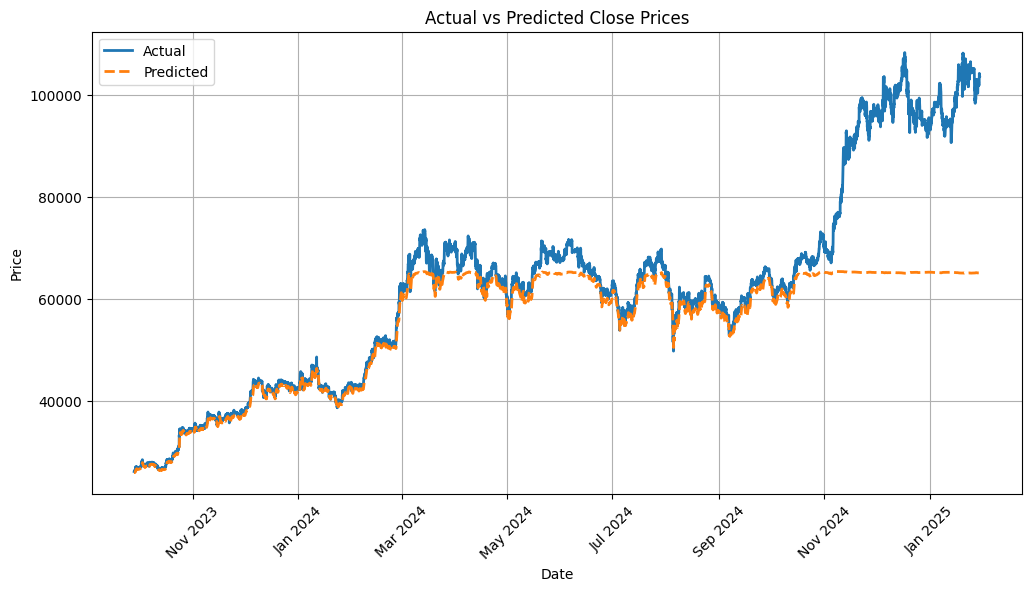

In [21]:
import matplotlib.dates as mdates

# Ensure the date index is in datetime format
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted with Month-Year Formatting
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_gru, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')

# Format the x-axis to show both Month and Year (e.g., Jan 2021, Apr 2022)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Show every 2nd month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Jan 2021'

plt.xticks(rotation=45)  # Rotate labels for better readability
plt.legend()
plt.grid(True)
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_gru)
mse = mean_squared_error(y_test_actual, predicted_gru)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_gru) / y_test_actual)) * 100  # In percentage
r2 = r2_score(y_test_actual, predicted_gru)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error (MAE): 6771.0153
Mean Squared Error (MSE): 179247210.8610
Root Mean Squared Error (RMSE): 13388.3237
Mean Absolute Percentage Error (MAPE): 7.81%
R-squared (R²): 0.5478


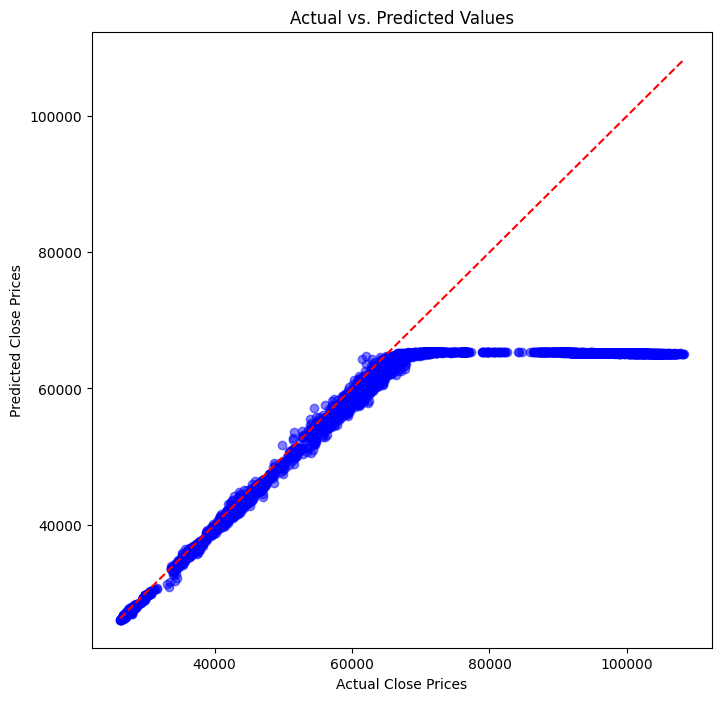

In [23]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, predicted_gru, alpha=0.5, color='blue')
plt.plot([min(y_test_actual), max(y_test_actual)], [min(y_test_actual), max(y_test_actual)], '--', color='red')  # Ideal line
plt.title("Actual vs. Predicted Values")
plt.xlabel("Actual Close Prices")
plt.ylabel("Predicted Close Prices")
plt.show()

### Implementing LSTM

In [24]:
from keras.layers import LSTM, Dropout, SimpleRNN

lstm_model = Sequential()

# First LSTM layer with dropout
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(Dropout(0.2))

# Second LSTM layer with dropout
lstm_model.add(LSTM(50, return_sequences=True))
lstm_model.add(Dropout(0.2))

# Third LSTM layer with dropout
lstm_model.add(LSTM(50, return_sequences=True))
lstm_model.add(Dropout(0.2))

# Fourth LSTM layer with dropout
lstm_model.add(LSTM(50))
lstm_model.add(Dropout(0.2))

# Output layer
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

lstm_model.summary()

/opt/anaconda3/envs/GRU_env/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 15, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 15, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 15, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 15, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,651 (279.89 KB)

 Trainable params: 71,651 (279.89 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Training 
lstm_model.fit(X_train, y_train, epochs=30, batch_size=24, verbose=1)

Epoch 1/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0014
Epoch 2/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 2.7210e-04
Epoch 3/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 2.5598e-04
Epoch 4/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 2.4153e-04
Epoch 5/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 2.3106e-04
Epoch 6/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 2.1014e-04
Epoch 7/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 2.1506e-04
Epoch 8/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 2.0639e-04
Epoch 9/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 1.9563e-04
Epoch 10/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 2.0180e-04
Epoch 11/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 1.9381e-04
Epoch 12/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 1.9665e-04
Epoch 13/30
1961/1961 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 1.8539e-04
Epoch 14/30
1961/1961 ━━━━━━━━━━━━━━━━

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


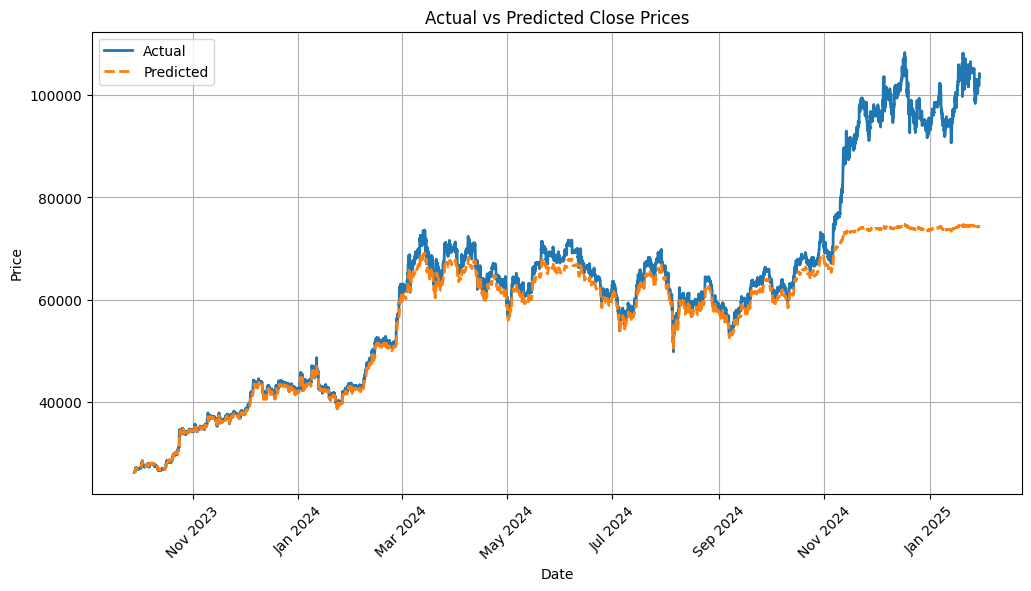

In [28]:
# Visualizing LSTM Model Predictions: Comparing Actual and Predicted Data

# Make predictions
predicted_lstm = lstm_model.predict(X_test)

# Inverse transform the predicted and actual values using the correct scaler
predicted_lstm = close_scaler.inverse_transform(predicted_lstm)  # Use close_scaler
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))  # Ensure correct shape

# Extract the date index for the test set
date_index = pd.to_datetime(data.index[-len(y_test_actual):])

# Plot Actual vs Predicted Prices
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_lstm, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')

# Format x-axis to show Month-Year
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # Show every 2nd month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Jan 2021'

plt.xticks(rotation=45)  # Rotate labels for better readability
plt.legend()
plt.grid(True)
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Compute error metrics
mae = mean_absolute_error(y_test_actual, predicted_lstm)
mse = mean_squared_error(y_test_actual, predicted_lstm)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_lstm) / y_test_actual)) * 100  # In percentage
r2 = r2_score(y_test_actual, predicted_lstm)

# Print results
print(f"Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R²): {r2:.4f}")

Model Error Statistics:
Mean Absolute Error (MAE): 5040.3982
Mean Squared Error (MSE): 96764486.3093
Root Mean Squared Error (RMSE): 9836.8941
Mean Absolute Percentage Error (MAPE): 5.83%
R-squared (R²): 0.7559
